# Scoring `real_obd_001` against the KIT-trained anomaly model

One-time investigation notebook — not a repeatable pipeline script, unlike everything in `src/`.

**Scope reminder (architecture.md §3.13):** this checks *plausibility* — does your independently-collected
telemetry score as statistically normal against a model trained on genuine automotive data it's never seen.
It does **not** validate sensor accuracy against physical ground truth, and the model was trained on a
single vehicle (a KIT/RADAR Seat León) — cross-vehicle generalization is a real assumption, not a guarantee.

**Not in scope here:** writing a `telemetry_anomaly` table or touching Grafana — that's the deliberately
separate follow-up chat flagged in architecture.md §3.13, only worth doing once this notebook shows the
model's output is actually useful to look at.

In [13]:
import sys
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This notebook lives in analytics/notebooks/ — make analytics/src/ importable
SRC_DIR = Path("../src").resolve()
sys.path.append(str(SRC_DIR))

from db import query
from feature_engineering import build_features
from train_val_split import resample_trip


## 1. Pull `real_obd_001` telemetry

Same time-range join pattern used everywhere else in this project (schema-reference.md's "Implemented change" section) —
membership in a session is a time-range join, not a stored FK.

**Assumption flagged:** `params` below assumes `query()` accepts a dict for named placeholders (`%(session_id)s`),
the standard psycopg2 pattern. If your `db.py` expects positional params instead, swap this for whatever form it uses.

In [14]:
sql = """
    SELECT t.time AS timestamp, t.coolant_temp_c, t.rpm, t.speed_kmh
    FROM telemetry t
    JOIN sessions s
      ON t.time BETWEEN s.started_at AND COALESCE(s.ended_at, NOW())
    WHERE s.id = %(session_id)s
    ORDER BY t.time
"""

raw_df = query(sql, params={"session_id": "real_obd_001"})
print(f"Pulled {len(raw_df):,} rows")
raw_df.head()


Pulled 2,410 rows


,timestamp,coolant_temp_c,rpm,speed_kmh
0,2026-07-26 15:17:21.037710+05:30,44.0,0.0,0.0
1,2026-07-26 15:17:21.933809+05:30,44.0,0.0,0.0
2,2026-07-26 15:17:22.723591+05:30,44.0,0.0,0.0
3,2026-07-26 15:17:23.212319+05:30,44.0,0.0,0.0
4,2026-07-26 15:17:23.739199+05:30,44.0,0.0,0.0


## 2. Feature engineering — the exact same pipeline used on KIT

Reusing `build_features()` and `resample_trip()` directly from `src/`, not reimplementing them — this is what
guarantees the transform applied to your real data is identical to what the model was trained on.

Real data is one continuous session, not multiple discrete trips — but both functions operate per `trip_id`,
so we just assign the whole session `trip_id = 0` and reuse them unchanged.

In [15]:
raw_df["trip_id"] = 0

featured_df, feature_cols = build_features(raw_df)
print(f"After deviation features + cold-start trim: {len(featured_df):,} rows")

resampled_df = resample_trip(featured_df)
print(f"After 1Hz resampling: {len(resampled_df):,} rows")


Dropped 87 rows in the first 60s of each trip (2,410 -> 2,323)
Dropped 22 additional rows with residual NaNs in feature columns
After deviation features + cold-start trim: 2,301 rows
After 1Hz resampling: 1,572 rows


## 3. Score with the trained, calibrated model

In [16]:
MODEL_DIR = Path("../models").resolve()

model = joblib.load(MODEL_DIR / "isolation_forest_baseline.joblib")
with open(MODEL_DIR / "threshold_config.json") as f:
    config = json.load(f)
threshold = config["threshold"]

scores = model.decision_function(resampled_df[feature_cols])
resampled_df["anomaly_score"] = scores
resampled_df["is_anomalous"] = scores < threshold

pct_anomalous = resampled_df["is_anomalous"].mean() * 100
expected_pct = config["target_fpr_pct"]

print(f"real_obd_001: {pct_anomalous:.1f}% of driving flagged anomalous "
      f"(baseline expectation from KIT validation: {expected_pct:.1f}%)")

if pct_anomalous <= expected_pct * 2:
    print("-> Reads as broadly plausible against the KIT-trained baseline.")
else:
    print("-> Meaningfully elevated vs. baseline -- worth a closer look, "
          "not necessarily a real fault (see limitations at the end).")


real_obd_001: 16.7% of driving flagged anomalous (baseline expectation from KIT validation: 2.0%)
-> Meaningfully elevated vs. baseline -- worth a closer look, not necessarily a real fault (see limitations at the end).


In [17]:
# Diagnostic: how much of the elevated anomaly rate is explained by
# RPM==0 (hybrid EV-mode) or speed==0 (stationary) states the
# KIT-trained (pure ICE) model never learned as normal?

flagged = resampled_df["is_anomalous"]

print("--- Hypothesis 1: stationary vehicle (speed == 0) ---")
stationary = resampled_df["speed_kmh"] == 0
print(f"Stationary rows: {stationary.sum()} ({stationary.mean()*100:.1f}% of session)")
print(f"Anomaly rate WHILE stationary:     {flagged[stationary].mean()*100:.1f}%")
print(f"Anomaly rate WHILE moving:         {flagged[~stationary].mean()*100:.1f}%")

print("\n--- Hypothesis 2: RPM == 0 (hybrid EV-only mode) ---")
rpm_zero = resampled_df["rpm"] == 0
print(f"RPM==0 rows: {rpm_zero.sum()} ({rpm_zero.mean()*100:.1f}% of session)")
print(f"Anomaly rate WHEN rpm==0:          {flagged[rpm_zero].mean()*100:.1f}%")
print(f"Anomaly rate WHEN rpm>0:           {flagged[~rpm_zero].mean()*100:.1f}%")

print("\n--- Does the KIT training data ever see RPM==0 at all? ---")
kit_rpm_zero_pct = (kit_train_df["rpm_dev"] == kit_train_df["rpm_dev"].min()).mean()  # rough proxy
print(f"(Note: KIT's rpm column isn't in kit_train_df directly — rpm_dev is the "
      f"deviation. Rough check: min rpm_dev in training = {kit_train_df['rpm_dev'].min():.0f}, "
      f"vs. your hybrid's rpm_dev range: {resampled_df['rpm_dev'].min():.0f} to "
      f"{resampled_df['rpm_dev'].max():.0f})")

print("\n--- Combined: anomaly rate excluding BOTH stationary and rpm==0 rows ---")
clean = resampled_df[~stationary & ~rpm_zero]
print(f"Rows remaining: {len(clean):,} ({len(clean)/len(resampled_df)*100:.1f}% of session)")
print(f"Anomaly rate on this subset: {clean['is_anomalous'].mean()*100:.1f}%")

--- Hypothesis 1: stationary vehicle (speed == 0) ---
Stationary rows: 248 (15.8% of session)
Anomaly rate WHILE stationary:     6.0%
Anomaly rate WHILE moving:         18.7%

--- Hypothesis 2: RPM == 0 (hybrid EV-only mode) ---
RPM==0 rows: 1054 (67.0% of session)
Anomaly rate WHEN rpm==0:          5.1%
Anomaly rate WHEN rpm>0:           40.3%

--- Does the KIT training data ever see RPM==0 at all? ---
(Note: KIT's rpm column isn't in kit_train_df directly — rpm_dev is the deviation. Rough check: min rpm_dev in training = -1880, vs. your hybrid's rpm_dev range: -1699 to 2312)

--- Combined: anomaly rate excluding BOTH stationary and rpm==0 rows ---
Rows remaining: 502 (31.9% of session)
Anomaly rate on this subset: 39.4%


In [18]:
# Does 'time since RPM last was 0' predict getting flagged?
resampled_df["engine_on"] = resampled_df["rpm"] > 0
resampled_df["engine_on_group"] = (resampled_df["engine_on"] != resampled_df["engine_on"].shift()).cumsum()

# For each continuous engine-on stretch, how far into it is each row?
resampled_df["seconds_since_engine_start"] = resampled_df.groupby("engine_on_group").cumcount()

engine_on_rows = resampled_df[resampled_df["engine_on"]]
early = engine_on_rows[engine_on_rows["seconds_since_engine_start"] < 60]
later = engine_on_rows[engine_on_rows["seconds_since_engine_start"] >= 60]

print(f"Anomaly rate in first 60s after engine restart: {early['is_anomalous'].mean()*100:.1f}% ({len(early)} rows)")
print(f"Anomaly rate 60s+ into sustained engine-on:      {later['is_anomalous'].mean()*100:.1f}% ({len(later)} rows)")

Anomaly rate in first 60s after engine restart: 40.3% (518 rows)
Anomaly rate 60s+ into sustained engine-on:      nan% (0 rows)


## 4. Where do flags occur? Time-series view

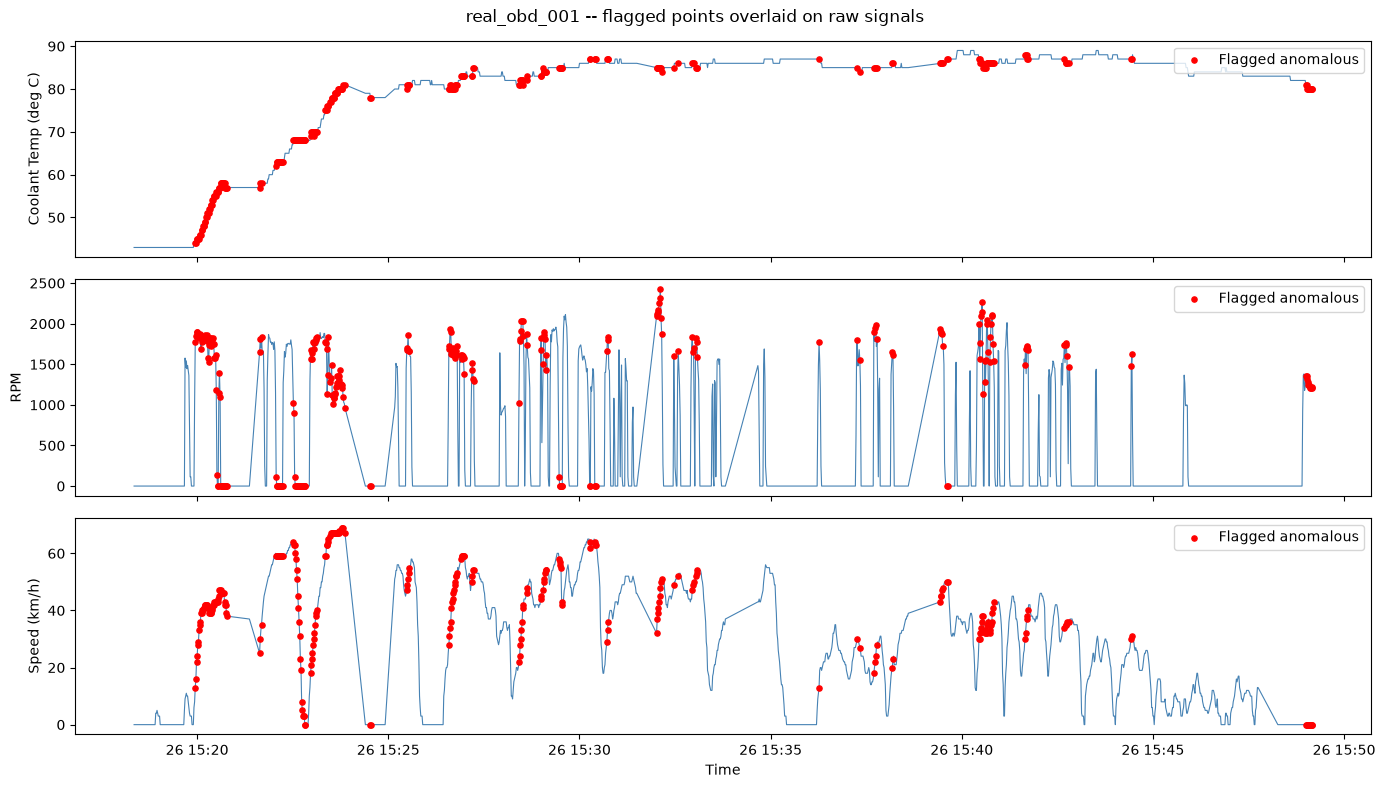

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
signals = [("coolant_temp_c", "Coolant Temp (deg C)"),
           ("rpm", "RPM"),
           ("speed_kmh", "Speed (km/h)")]

flagged = resampled_df[resampled_df["is_anomalous"]]

for ax, (col, label) in zip(axes, signals):
    ax.plot(resampled_df["timestamp"], resampled_df[col], color="steelblue", linewidth=0.8)
    ax.scatter(flagged["timestamp"], flagged[col], color="red", s=14, zorder=5, label="Flagged anomalous")
    ax.set_ylabel(label)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Time")
fig.suptitle("real_obd_001 -- flagged points overlaid on raw signals")
plt.tight_layout()
plt.show()


## 5. Score distribution vs. the KIT baseline

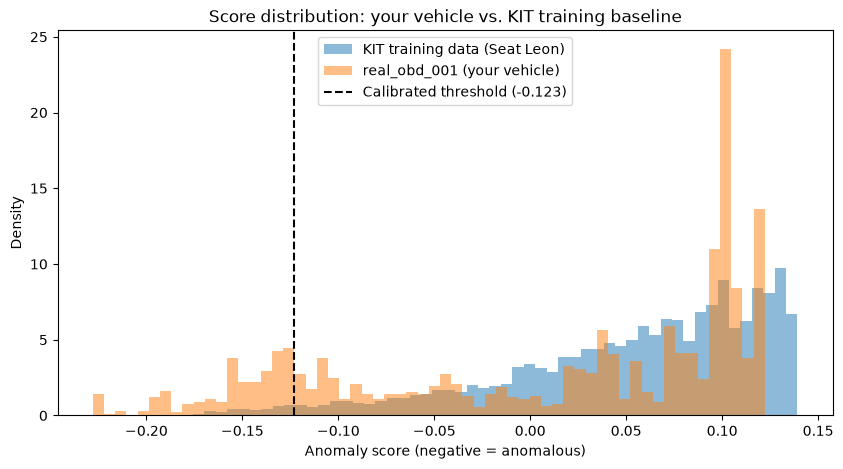

In [7]:
DATA_DIR = Path("../dataset/processed").resolve()
kit_train_df = pd.read_parquet(DATA_DIR / "kit_train.parquet")
kit_train_scores = model.decision_function(kit_train_df[feature_cols])

plt.figure(figsize=(10, 5))
plt.hist(kit_train_scores, bins=60, alpha=0.5, density=True, label="KIT training data (Seat Leon)")
plt.hist(scores, bins=60, alpha=0.5, density=True, label="real_obd_001 (your vehicle)")
plt.axvline(threshold, color="black", linestyle="--", label=f"Calibrated threshold ({threshold:.3f})")
plt.xlabel("Anomaly score (negative = anomalous)")
plt.ylabel("Density")
plt.legend()
plt.title("Score distribution: your vehicle vs. KIT training baseline")
plt.show()


## 6. Limitations, stated plainly

- **Single-vehicle training baseline.** The model only ever saw one car's (a KIT/RADAR Seat Leon's) normal
  operating envelope. A different, equally healthy vehicle's true baseline could legitimately look different
  in absolute terms -- this is exactly why coolant/RPM were engineered as *relative* (rolling-deviation) features
  rather than raw values, but it doesn't eliminate the risk, only reduce it.
- **Plausibility, not accuracy.** A low anomaly rate here is evidence your data isn't statistically weird
  relative to genuine automotive telemetry -- it is not a claim that your sensors are correctly calibrated
  against physical ground truth.
- **Three features only** (coolant deviation, RPM deviation, speed) -- throttle/pedal position, GPS, and IMU
  data play no role in this score at all.
- **No labeled real faults.** Detection performance was only ever measured against synthetic, disclosed,
  injected faults -- not a real fault this vehicle has actually experienced.

**Next step, if this looks stable and useful:** a batch-scored `telemetry_anomaly` table (written via DBeaver,
same manual-bootstrap pattern used elsewhere in this project) joined against `sessions`, surfaced on its own
dedicated Grafana dashboard -- tracked as a separate follow-up chat, not started here.